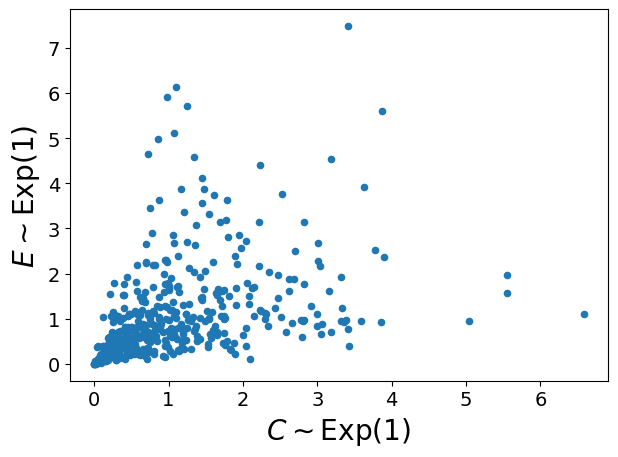

In [ ]:
# Notebook cell: Clayton copula sampling -> Exp(1) marginals -> scatter plot
import torch
import numpy as np
import config as cfg

matplotlib_style = 'default'
import matplotlib.pyplot as plt; plt.style.use(matplotlib_style)
plt.rcParams.update({'axes.labelsize': 'x-large',
                     'axes.titlesize': 'x-large',
                     'font.size': 14.0})

# Clayton copula sampler (Archimedean, theta > 0)
# Uses the Marshall–Olkin representation:
#   W ~ Gamma(shape=1/theta, scale=1)
#   E1,E2 ~ Exp(1) iid
#   Ui = (1 + Ei/W)^(-1/theta)
def sample_clayton_uv(n: int, theta: float, device="cpu", dtype=torch.float64):
    assert theta > 0, "Clayton theta must be > 0 for this sampler."
    # Gamma(shape=k, scale=1)
    shape = torch.tensor([1.0/theta], device=device, dtype=dtype)
    gamma = torch.distributions.Gamma(concentration=shape, rate=torch.tensor([1.0], device=device, dtype=dtype))
    W = gamma.sample((n,)).squeeze(-1)  # (n,)
    exp = torch.distributions.Exponential(rate=torch.tensor([1.0], device=device, dtype=dtype))
    E = exp.sample((n, 2)).squeeze(-1)  # (n,2)
    U = (1.0 + E / W[:, None]).pow(-1.0/theta)
    # Clamp for numerical safety
    eps = torch.finfo(dtype).eps
    return U.clamp(eps, 1.0 - eps)

def exp_icdf(u: torch.Tensor, rate: float = 1.0):
    # Exp(rate) inverse CDF: F^{-1}(u) = -log(1-u)/rate
    return -torch.log1p(-u) / rate

# Parameters
n = 500
theta = 2.0  # pick something > 0; larger => stronger lower-tail dependence
device = "cpu"
dtype = torch.float64

# Generate samples
U = sample_clayton_uv(n, theta, device=device, dtype=dtype)
E = exp_icdf(U[:, 0], rate=1.0)  # E ~ Exp(1)
C = exp_icdf(U[:, 1], rate=1.0)  # C ~ Exp(1)

# Plot
plt.figure()
plt.scatter(C.cpu().numpy(), E.cpu().numpy(), s=20)
plt.xlabel(r"$C \sim \mathrm{Exp}(1)$")
plt.ylabel(r"$E \sim \mathrm{Exp}(1)$")
plt.tight_layout()
plt.show()

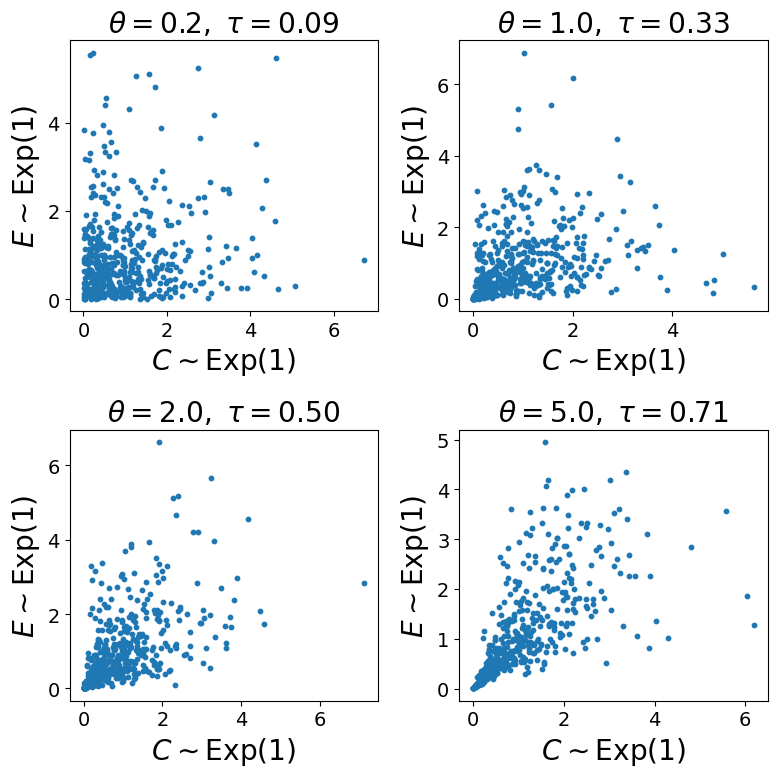

In [ ]:
# Notebook cell: 2x2 Clayton copula plots with Kendall's tau in titles

import torch
import numpy as np
import matplotlib.pyplot as plt
from utility.survival import theta_to_kendall_tau

# Clayton copula sampler (Marshall–Olkin) ----
def sample_clayton_uv(n: int, theta: float, device="cpu", dtype=torch.float64):
    assert theta > 0, "Clayton theta must be > 0."
    shape = torch.tensor([1.0/theta], device=device, dtype=dtype)
    gamma = torch.distributions.Gamma(concentration=shape,
                                      rate=torch.tensor([1.0], device=device, dtype=dtype))
    W = gamma.sample((n,)).squeeze(-1)  # (n,)
    exp = torch.distributions.Exponential(rate=torch.tensor([1.0], device=device, dtype=dtype))
    E = exp.sample((n, 2)).squeeze(-1)  # (n,2)
    U = (1.0 + E / W[:, None]).pow(-1.0/theta)
    eps = torch.finfo(dtype).eps
    return U.clamp(eps, 1.0 - eps)

def exp_icdf(u: torch.Tensor, rate: float = 1.0):
    return -torch.log1p(-u) / rate

# Settings
n = 500
thetas = [0.2, 1.0, 2.0, 5.0]  # increasing dependence
device = "cpu"
dtype = torch.float64

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, theta in zip(axes.flatten(), thetas):
    U = sample_clayton_uv(n, theta, device=device, dtype=dtype)
    E = exp_icdf(U[:, 0])
    C = exp_icdf(U[:, 1])

    tau = theta_to_kendall_tau("clayton", theta)

    ax.scatter(C.cpu().numpy(), E.cpu().numpy(), s=10)
    ax.set_title(rf"$\theta={theta},\ \tau={tau:.2f}$")
    ax.set_xlabel(r"$C \sim \mathrm{Exp}(1)$")
    ax.set_ylabel(r"$E \sim \mathrm{Exp}(1)$")

plt.tight_layout()
plt.savefig(f"{cfg.PLOTS_DIR}/clayton_copula.pdf", format='pdf', bbox_inches='tight')
plt.show()